# Model #

I try to put down a model. I will use the xor-perceptron model as a base and modify that.

first create the lattice, N by N, with Nsol = N**2

I should create a class for the cell object and then the network class is formed by cell objects and when the network is created, each network is associated with a position in the lattice.

Note: for now I'm only considering one possible link between each pair neuron for each direction

In [1]:
import numpy as np
from numpy import random as nrd
import matplotlib.pyplot as plt
import graph_tool as gt
from graph_tool.all import *
import matplotlib.animation as animation
import seaborn as sns

import model_ricard as m       # I've put all the functions in a separate Python file

In [2]:
# parameters of the simulation
par={'L': 4,                    # side length of the squared lattice
     'p_self_link': 0,         # probability for each cell of having a self link
     'C_density': 1,                       # initial density of links
     'J_range': [-1,+1],                       # define the possible value for J.
     'gamma': 2,                             # gamma parameter of the Boltzmann function (transfer function)
     'tau': 600,                                   # temperature parameter for the softmax 
     'crossover_ratio': 0,                    # percentage of offspring to be generated by crossover + mutation (instead of only mutation)
     'target_set': [-1.0,1.0,1.0,-1.0],
     'input_set':[[-1,-1],[-1,1],[1,-1],[1,1]],
     'majority_ratio': None,                       # output = np.mean(state[int(par['majority_ratio']*par['L']):-1]); if None, output = state[-1]
     'ff_iter': 4,                               # number of iterations the ff is executed for computing the output of a network (to reach the steady state)
     'J_mutation_radius': 0.05,                 # standard deviation of the normal distribution used to sample the mutation value for J.
     'B_mutation_radius': 0.05,            # standard deviation of the normal distribution used to sample the mutation value for B.
     'T_mutation_radius': 0.1,           # standard deviation of the normal distribution used to sample the mutation value for T = T_mutation_radius * L
     'reproduction_ratio': 0.2,          # percentage of offsprings to be generated by reproduction (the reamining by random generation)
     'elitist_ratio':0.5,
     #'x_n': np.linspace(-1,1,64),   # discretization of the input of the transfer function (last argmument 
                                   # is also the maximum number of non-zero coefficients in the DFT of the 
                                   # transfer function. it should be a power of 2 for best performance of fft)
     'n_iter': 1000,                    # number of iterations of the algorithm
     'early_stop_ratio': 0.9,           # ratio of solutions to have loss < 0.01 for early stop to trigger
     'rndm_gen_stop': 0.01,                  # best loss lower threshold for halting random generation
     'add_weights': 0.01,                    # best loss lower threshold for adding the weights cost to the loss function
     'N_sol': 200}                       # number of solutions (individuals, networks) considered in the simulation

if par['reproduction_ratio'] + par['elitist_ratio'] > 1:
     print(f'Error: expected sum of reproduction ratio and elitist ratio to be at maximum 1, but instead got {par[
          'reproduction_ratio']} + {par['elitist_ratio']} = {par['reproduction_ratio']+par['elitist_ratio']}')

nrd.seed(1234)

In [3]:
solutions, lmean, mean_t_dist, mean_weight_cost, loss_ev, mean_asp,T_values, mean_volume = m.evolution(par,verb=1,gen_verb=False,stat=True,early_stop=False)

/home/ubuntu/ne/main/model_ricard.py:210: RuntimeWarning: divide by zero encountered in divide
  par['p_self_link'],1/dist_matrix)        # link probability decays exponentially with the distance (from literature,


Iteration #0...
Mean loss: 1.0000008979792847
Best loss: 0.9998838054900258
Cumulative Best loss: 0.9998838054900258
Mean target distance: 1.0000008979792847
Mean weight cost: 0.23346313058299503
Mean volume: 0.85544921875
Iteration #100...
Mean loss: 0.7285658520052523
Best loss: 0.5000099722096204
Cumulative Best loss: 0.5000099722096204
Mean target distance: 0.7285658520052523
Mean weight cost: 0.1414419895927802
Mean volume: 0.41974609375
Iteration #200...
Mean loss: 0.7379150221098986
Best loss: 0.5000001143133065
Cumulative Best loss: 0.5000001143133065
Mean target distance: 0.7379150221098986
Mean weight cost: 0.13483526953331576
Mean volume: 0.41970703125
Iteration #300...
Mean loss: 0.7334319905873246
Best loss: 0.5000000015686429
Cumulative Best loss: 0.5000000015686429
Mean target distance: 0.7334319905873246
Mean weight cost: 0.1326875736475305
Mean volume: 0.41974609375
Iteration #400...
Mean loss: 0.7255000249401149
Best loss: 0.4999999204984563
Cumulative Best loss: 0.49

In [4]:
losses = []
for n,sol in enumerate(solutions[:10]):
    print(f'Solution #{n}')
    loss,_,_ = m.compute_loss(sol,par,verb=True)
    losses.append(loss)
    print(f'loss:{loss}')

Solution #0
Input: [-1, -1] -> Output: -0.999954411659623
Target distance:4.558834037704518e-05
Input: [-1, 1] -> Output: 0.9999260421011122
Target distance:7.395789888775539e-05
Input: [1, -1] -> Output: 0.9999999404416551
Target distance:5.955834492255008e-08
Input: [1, 1] -> Output: -0.9958346902229641
Target distance:0.004165309777035886
loss:0.0010712288936614023
Solution #1
Input: [-1, -1] -> Output: -0.999986795332758
Target distance:1.3204667241972778e-05
Input: [-1, 1] -> Output: 0.999999999995576
Target distance:4.424016708526324e-12
Input: [1, -1] -> Output: 0.9999999999338858
Target distance:6.611422520563792e-11
Input: [1, 1] -> Output: -0.979573555161733
Target distance:0.020426444838267055
loss:0.005109912394011817
Solution #2
Input: [-1, -1] -> Output: -0.9953019566663487
Target distance:0.004698043333651314
Input: [-1, 1] -> Output: 0.9999999782504967
Target distance:2.1749503309465013e-08
Input: [1, -1] -> Output: 0.9999999983644403
Target distance:1.6355596876849177e

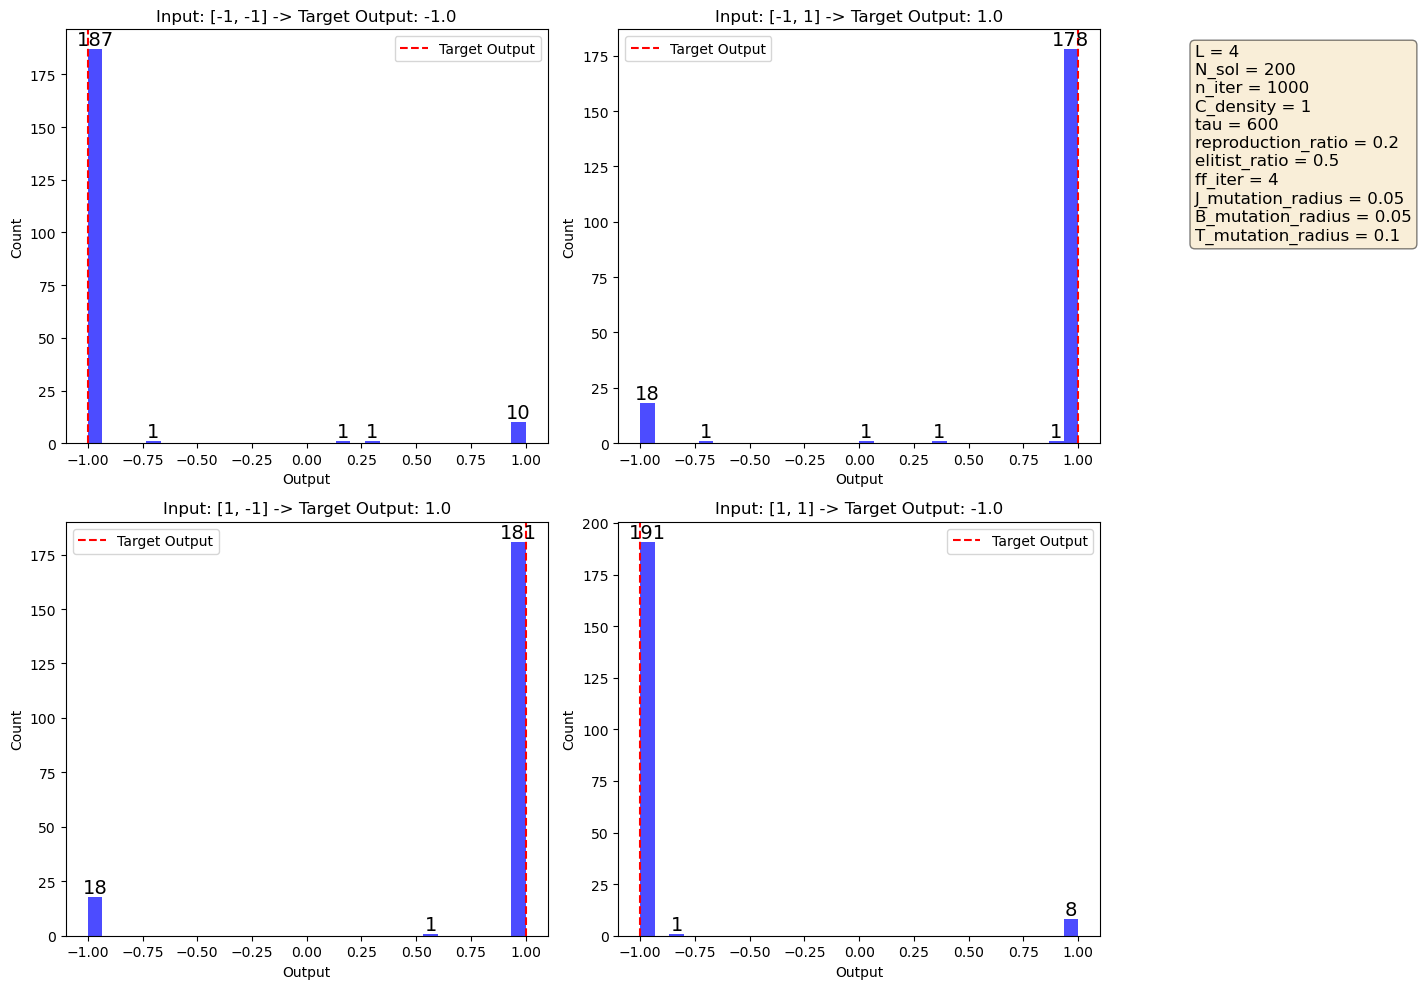

In [5]:
outputs = np.zeros((len(solutions), len(par['input_set'])))
for n, sol in enumerate(solutions):
    for i, input in enumerate(par['input_set']):
        output = m.ff(input, sol, par)
        outputs[n, i] = output

fig, axes = plt.subplots(2, len(par['input_set']) // 2, figsize=(16, 10))
axes = axes.flatten()
for i, ax in enumerate(axes):
    ax.hist(outputs[:, i], bins=30, alpha=0.7, color='b')
    ax.set_title(f'Input: {par["input_set"][i]} -> Target Output: {par["target_set"][i]}')
    ax.set_xlabel('Output')
    ax.set_ylabel('Count')
    ax.axvline(par['target_set'][i], label='Target Output', color='r', linestyle='--')
    for patch in ax.patches:
        height = patch.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}',
                        (patch.get_x() + patch.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=14)
    ax.legend()

# Prepare parameter text
param_text = (
    f"L = {par['L']}\n"
    f"N_sol = {par['N_sol']}\n"
    f"n_iter = {par['n_iter']}\n"
    f"C_density = {par['C_density']}\n"
    f"tau = {par['tau']}\n"
    f"reproduction_ratio = {par['reproduction_ratio']}\n"
    f"elitist_ratio = {par['elitist_ratio']}\n"
    f"ff_iter = {par['ff_iter']}\n"
    f"J_mutation_radius = {par['J_mutation_radius']}\n"
    f"B_mutation_radius = {par['B_mutation_radius']}\n"
    f"T_mutation_radius = {par['T_mutation_radius']}"
)

# Add parameter box
fig.text(0.75, 0.95, param_text, fontsize=12, va='top', ha='left',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout(rect=[0, 0, 0.7, 1])
plt.savefig('plots/IO.png')
plt.show()
plt.close(fig)

In [21]:
n=2

In [40]:
from matplotlib.gridspec import GridSpec

print(f'Links density:{np.sum(solutions[n].C)/solutions[n].C.shape[0]**2}')

graph = solutions[n].G

highlight = graph.new_vertex_property('int')
highlight[graph.vertex(par['L']//2)] = 1
highlight[graph.vertex(2*par['L'])] = 1
if par['majority_ratio'] is not None:
    for i in range(int(par['majority_ratio']*(par['L']**2)), graph.num_vertices()):
        highlight[graph.vertex(i)] = 2
else: 
    highlight[graph.vertex(par['L']**2-1)] = 2

fig = plt.figure(figsize=(14, 6))
gs = GridSpec(1, 2, width_ratios=[1, 1.2], figure=fig)

# Graph plot
ax1 = fig.add_subplot(gs[0])
graph_draw(
    graph,
    vertex_text=graph.vertex_index,
    vertex_fill_color=highlight,
    vcmap=plt.cm.Set1,
    mplfig=ax1,
    edge_color='black',
)
ax1.set_title(f'Network Graph of Solution #{n}', fontsize=14)
ax1.set_aspect('equal')

# Prepare mask for highlighting input and output cells
mask = np.zeros((par['L'], par['L']), dtype=bool)
highlight_colors = np.full((par['L'], par['L']), '', dtype=object)
input_indices = [par['L']//2, 2*par['L']]
output_index = par['L']**2 - 1
for idx in input_indices:
    y, x = divmod(idx, par['L'])
    highlight_colors[y, x] = 'input'
y, x = divmod(output_index, par['L'])
highlight_colors[y, x] = 'output'

# Heatmap plot
ax2 = fig.add_subplot(gs[1])
sns.heatmap(
    solutions[n].T.reshape(par['L'], par['L']),
    xticklabels=np.arange(1, par['L']+1),
    yticklabels=np.arange(1, par['L']+1),
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidths=.5,
    vmin=np.min(solutions[n].T),
    vmax=np.max(solutions[n].T),
    ax=ax2
)
ax2.set(xlabel="X Coordinate", ylabel="Y Coordinate")
ax2.set_title(f'Gain Parameter Distribution of Solution #{n}')
ax2.xaxis.tick_top()
ax2.set_aspect('equal')
for (y, x), label in np.ndenumerate(highlight_colors):
    if label == 'input':
        ax2.add_patch(plt.Rectangle((x, y), 1, 1, fill=False, edgecolor='deepskyblue', lw=3))
    elif label == 'output':
        ax2.add_patch(plt.Rectangle((x, y), 1, 1, fill=False, edgecolor='red', lw=3))

fig.text(0.72, 0.95, param_text, fontsize=12, va='top', ha='left',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout(rect=[0, 0, 0.7, 1])
plt.savefig(f'plots/graph_sol{n}.png')
plt.close(fig)

Links density:0.19921875


Graph of network #1 with gain parameter color plot 
Gain parameter: [ -5.19755346   8.78988015  -8.48223416   7.03818362  -7.71582573
  -5.39359245  -4.16335575  -3.48469666   8.13105712   9.13043152
  -8.67415394   1.06451907  -4.72094331  -5.99055597   6.57165375
 -14.46450606]


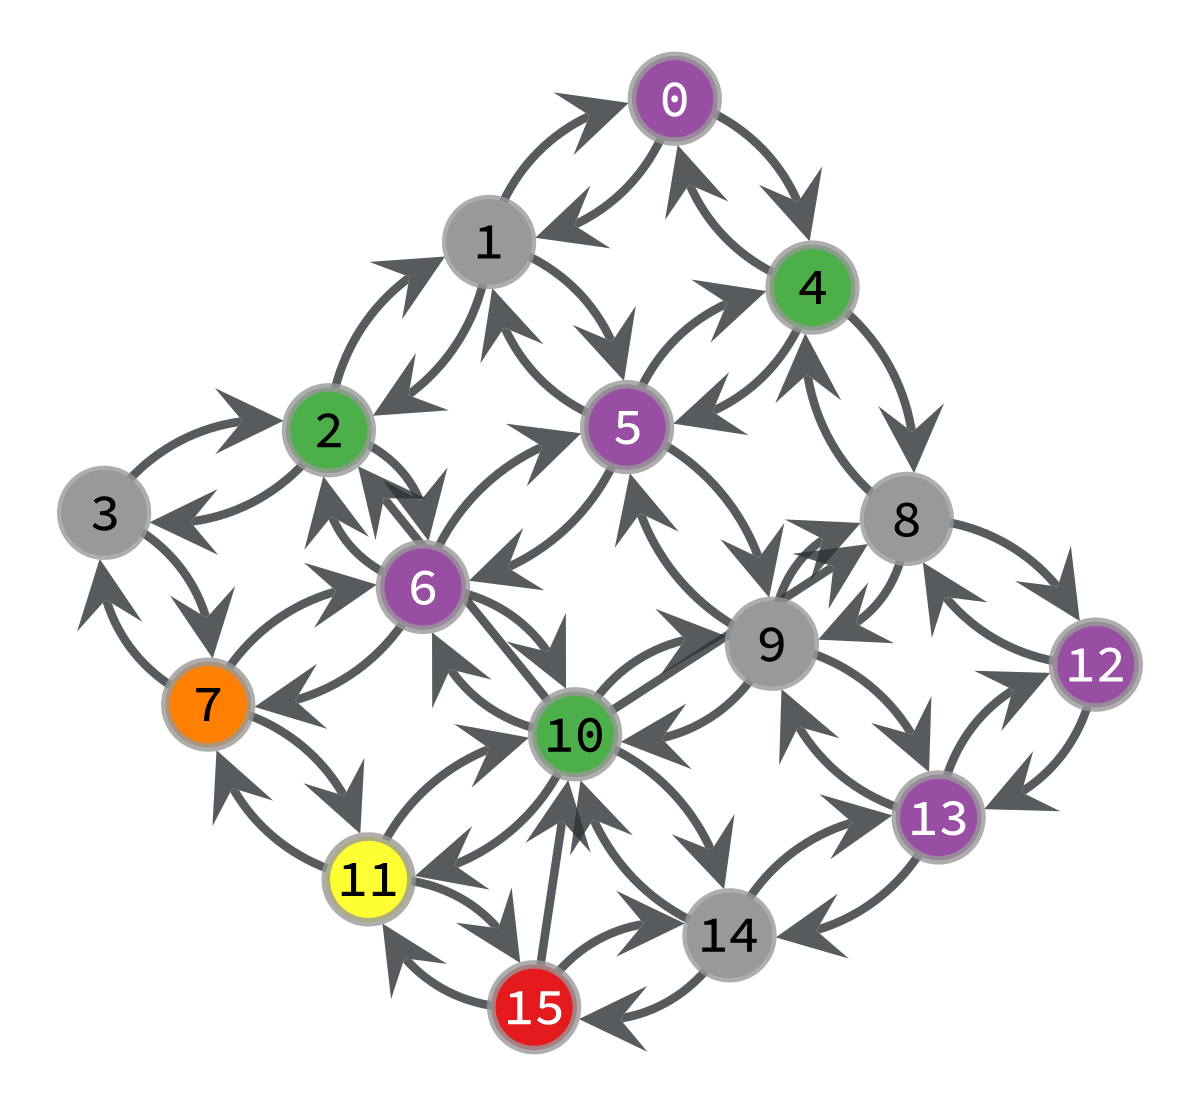

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7f127e905f90, at 0x7f126ff79d30>

In [18]:
print(f'Graph of network #{n} with gain parameter color plot ')
print(f'Gain parameter: {solutions[n].T}')

graph = solutions[n].G

highlight = graph.new_vertex_property('float')
for i in range(par['L']**2):
    highlight[graph.vertex(i)] = solutions[n].T[i]

graph_draw(
    graph,
    vertex_text=graph.vertex_index,
    vertex_fill_color=highlight,
    vcmap=plt.cm.Set1
)

In [9]:
sol = sorted(solutions, key=lambda sol: sol.loss)
for i,input in enumerate(par['input_set']):
    output = m.ff(input,sol[0],par,verb=0)
    print(f'Input:{input} -> Output:{output} -- Expected:{par['target_set'][i]}')

Input:[-1, -1] -> Output:-0.9999862132341145 -- Expected:-1.0
Input:[-1, 1] -> Output:0.9999999721289736 -- Expected:1.0
Input:[1, -1] -> Output:0.9999752464106308 -- Expected:1.0
Input:[1, 1] -> Output:-0.9999670621882359 -- Expected:-1.0


In [10]:
'''
data = np.mean(T_values,axis=0)

fig, ax = plt.subplots(figsize=(8, 6))

param_text = (
    f"L = {par['L']}\n"
    f"N_sol = {par['N_sol']}\n"
    f"n_iter = {par['n_iter']}\n"
    f"C_density = {par['C_density']}\n"
    f"tau = {par['tau']}\n"
    f"reproduction_ratio = {par['reproduction_ratio']}\n"
    f"elitist_ratio = {par['elitist_ratio']}\n"
    f"ff_iter = {par['ff_iter']}\n"
    f"J_mutation_radius = {par['J_mutation_radius']}\n"
    f"B_mutation_radius = {par['B_mutation_radius']}\n"
    f"T_mutation_radius = {par['T_mutation_radius']}"
)

# Move parameter box to the right and center vertically
fig.text(0.98, 0.5, param_text, fontsize=12, va='center', ha='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Use fixed bins for all frames to ensure visibility
bins = np.linspace(np.min(data), np.max(data), 50)

def animate(i):
    ax.clear()
    ax.hist(data[:, i], bins=bins, color='b', alpha=0.7)
    ax.set_title(f'Mean Gain Histogram at Iteration {i+1}')
    ax.set_xlabel('Gain')
    ax.set_ylabel('Cells Population')
    ax.set_xlim(np.min(data), np.max(data))
    ax.set_ylim(0, par['L']**2)

ani = animation.FuncAnimation(fig, animate, frames=data.shape[1], interval=50)

ani.save('plots/gain_evolution.gif', writer='pillow')
plt.close(fig)
'''

'\ndata = np.mean(T_values,axis=0)\n\nfig, ax = plt.subplots(figsize=(8, 6))\n\nparam_text = (\n    f"L = {par[\'L\']}\n"\n    f"N_sol = {par[\'N_sol\']}\n"\n    f"n_iter = {par[\'n_iter\']}\n"\n    f"C_density = {par[\'C_density\']}\n"\n    f"tau = {par[\'tau\']}\n"\n    f"reproduction_ratio = {par[\'reproduction_ratio\']}\n"\n    f"elitist_ratio = {par[\'elitist_ratio\']}\n"\n    f"ff_iter = {par[\'ff_iter\']}\n"\n    f"J_mutation_radius = {par[\'J_mutation_radius\']}\n"\n    f"B_mutation_radius = {par[\'B_mutation_radius\']}\n"\n    f"T_mutation_radius = {par[\'T_mutation_radius\']}"\n)\n\n# Move parameter box to the right and center vertically\nfig.text(0.98, 0.5, param_text, fontsize=12, va=\'center\', ha=\'right\',\n         bbox=dict(boxstyle=\'round\', facecolor=\'wheat\', alpha=0.5))\n\n# Use fixed bins for all frames to ensure visibility\nbins = np.linspace(np.min(data), np.max(data), 50)\n\ndef animate(i):\n    ax.clear()\n    ax.hist(data[:, i], bins=bins, color=\'b\', alph

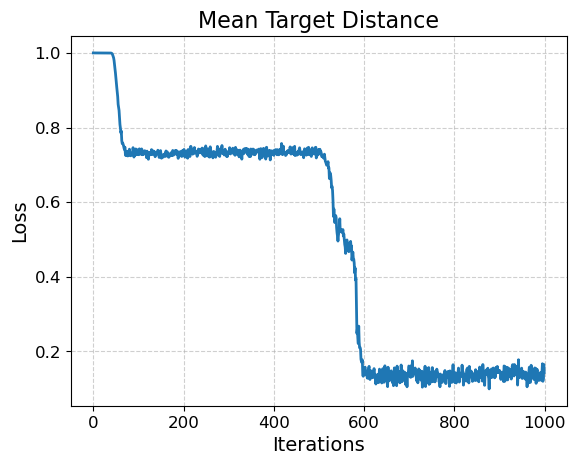

In [11]:
plt.plot(mean_t_dist, color='tab:blue', linewidth=2)
plt.title('Mean Target Distance', fontsize=16)
plt.xlabel('Iterations', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tick_params(axis='both', labelsize=12)

/tmp/ipykernel_961589/1569523596.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20', num_lines)


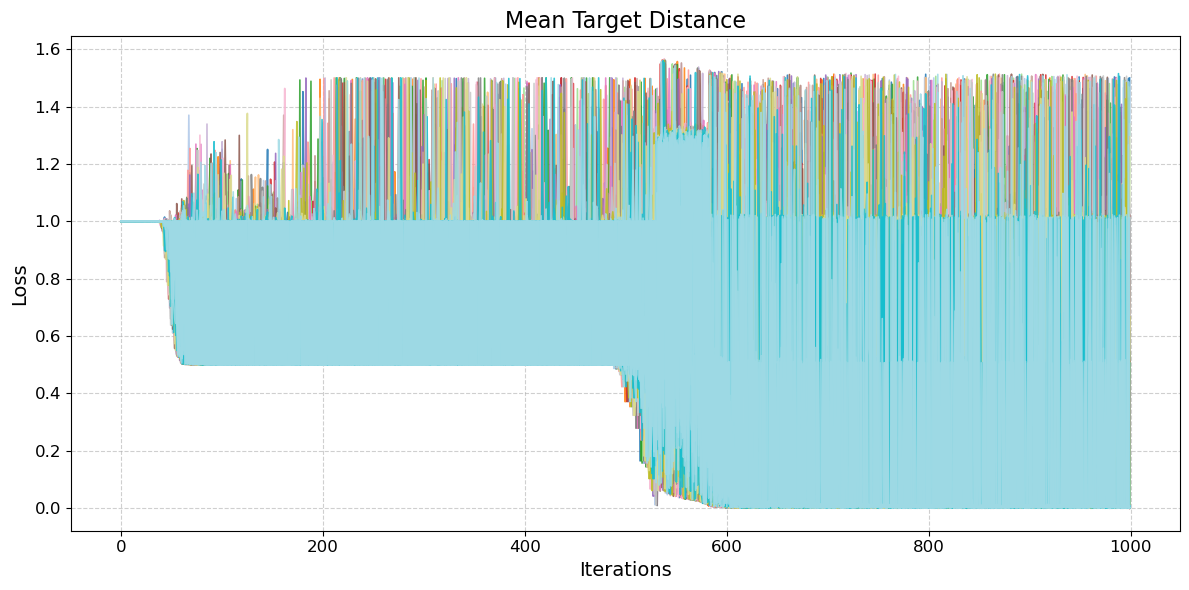

In [12]:
import matplotlib.cm as cm

num_lines = loss_ev.shape[0]
colors = cm.get_cmap('tab20', num_lines)

plt.figure(figsize=(12, 6))
for s in range(num_lines):
    plt.plot(loss_ev[s, :], linewidth=1.2, color=colors(s), alpha=0.85)
plt.title('Mean Target Distance', fontsize=16)
plt.xlabel('Iterations', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()

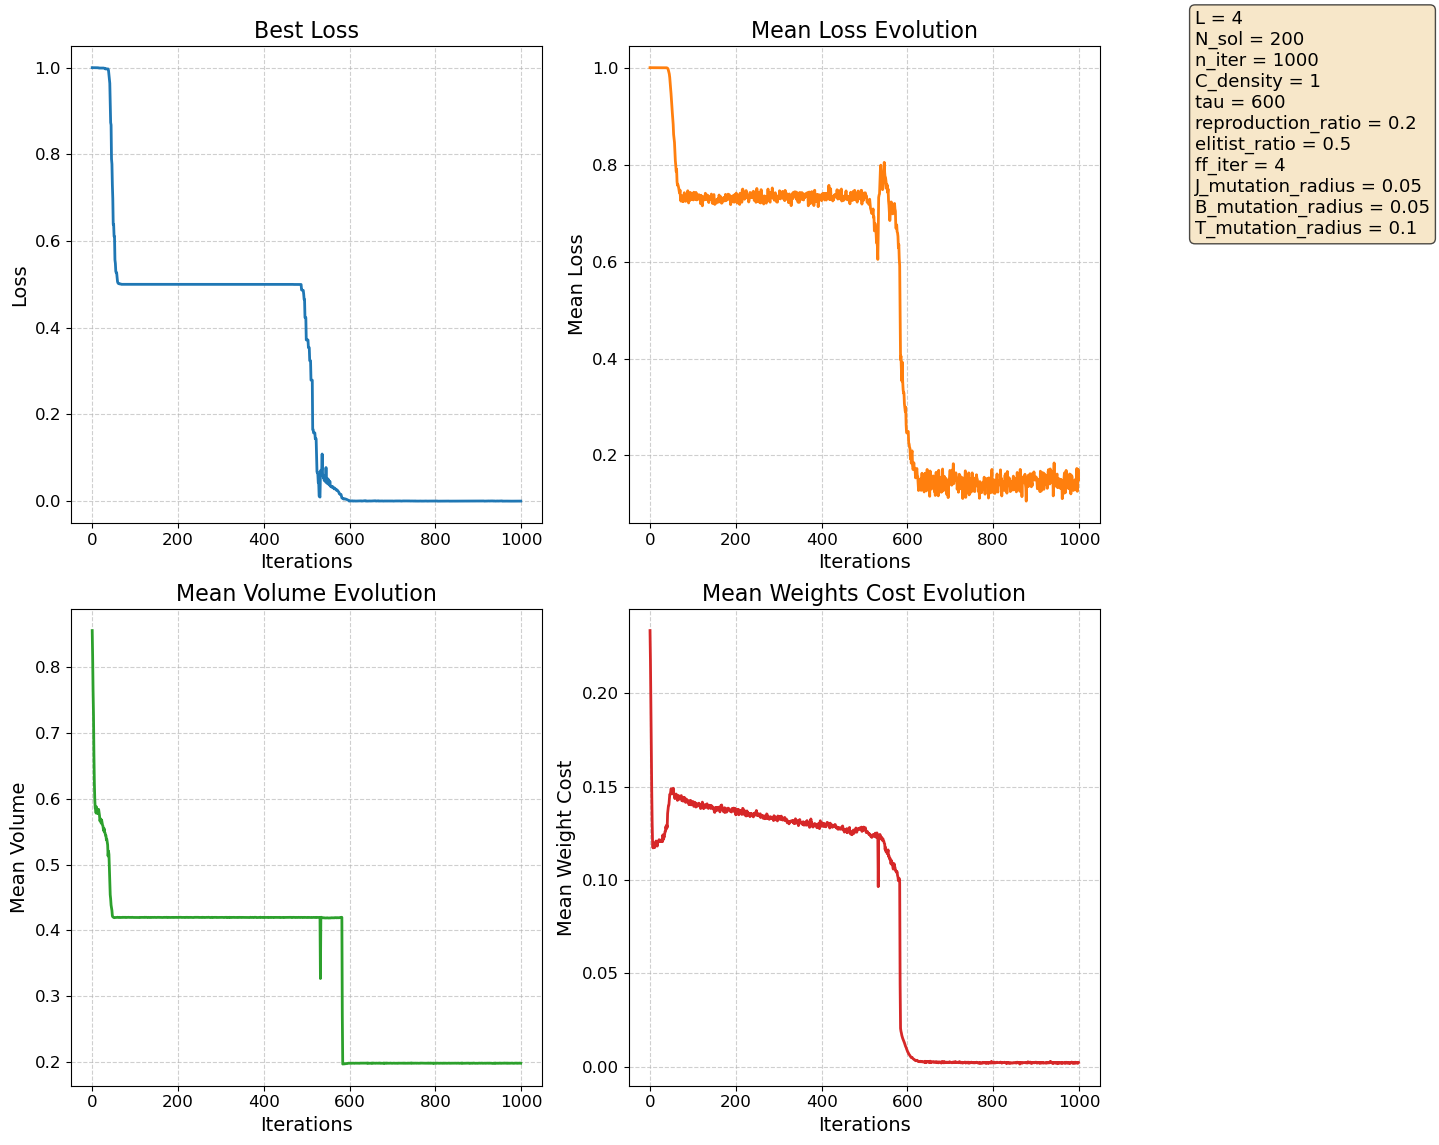

In [13]:
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# Best Loss
best_loss = np.min(loss_ev, axis=0)
axs[0, 0].plot(best_loss, color='tab:blue', linewidth=2)
axs[0, 0].set_title('Best Loss', fontsize=16)
axs[0, 0].set_xlabel('Iterations', fontsize=14)
axs[0, 0].set_ylabel('Loss', fontsize=14)
axs[0, 0].grid(True, linestyle='--', alpha=0.6)
axs[0, 0].tick_params(axis='both', labelsize=12)

# Mean Loss Evolution
axs[0, 1].plot(lmean, color='tab:orange', linewidth=2)
axs[0, 1].set_title('Mean Loss Evolution', fontsize=16)
axs[0, 1].set_xlabel('Iterations', fontsize=14)
axs[0, 1].set_ylabel('Mean Loss', fontsize=14)
axs[0, 1].grid(True, linestyle='--', alpha=0.6)
axs[0, 1].tick_params(axis='both', labelsize=12)

'''
# Mean Average Shortest Path Evolution
axs[1, 0].plot(mean_asp, color='tab:green', linewidth=2)
axs[1, 0].set_title('Mean Average Shortest Path Evolution', fontsize=16)
axs[1, 0].set_xlabel('Iterations', fontsize=14)
axs[1, 0].set_ylabel('Mean Length', fontsize=14)
axs[1, 0].grid(True, linestyle='--', alpha=0.6)
axs[1, 0].tick_params(axis='both', labelsize=12)
'''
# Mean Volume Evolution
axs[1, 0].plot(mean_volume, color='tab:green', linewidth=2)
axs[1, 0].set_title('Mean Volume Evolution', fontsize=16)
axs[1, 0].set_xlabel('Iterations', fontsize=14)
axs[1, 0].set_ylabel('Mean Volume', fontsize=14)
axs[1, 0].grid(True, linestyle='--', alpha=0.6)
axs[1, 0].tick_params(axis='both', labelsize=12)

# Mean Weights Cost Evolution
axs[1, 1].plot(mean_weight_cost, color='tab:red', linewidth=2)
axs[1, 1].set_title('Mean Weights Cost Evolution', fontsize=16)
axs[1, 1].set_xlabel('Iterations', fontsize=14)
axs[1, 1].set_ylabel('Mean Weight Cost', fontsize=14)
axs[1, 1].grid(True, linestyle='--', alpha=0.6)
axs[1, 1].tick_params(axis='both', labelsize=12)

# Prepare parameter text
param_text = (
    f"L = {par['L']}\n"
    f"N_sol = {par['N_sol']}\n"
    f"n_iter = {par['n_iter']}\n"
    f"C_density = {par['C_density']}\n"
    f"tau = {par['tau']}\n"
    f"reproduction_ratio = {par['reproduction_ratio']}\n"
    f"elitist_ratio = {par['elitist_ratio']}\n"
    f"ff_iter = {par['ff_iter']}\n"
    f"J_mutation_radius = {par['J_mutation_radius']}\n"
    f"B_mutation_radius = {par['B_mutation_radius']}\n"
    f"T_mutation_radius = {par['T_mutation_radius']}"
)

# Add parameter box
fig.text(0.75, 0.95, param_text, fontsize=13, va='top', ha='left',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout(rect=[0, 0, 0.7, 1])
plt.subplots_adjust(top=0.92)
plt.savefig('plots/loss.png', dpi=150)
plt.show()


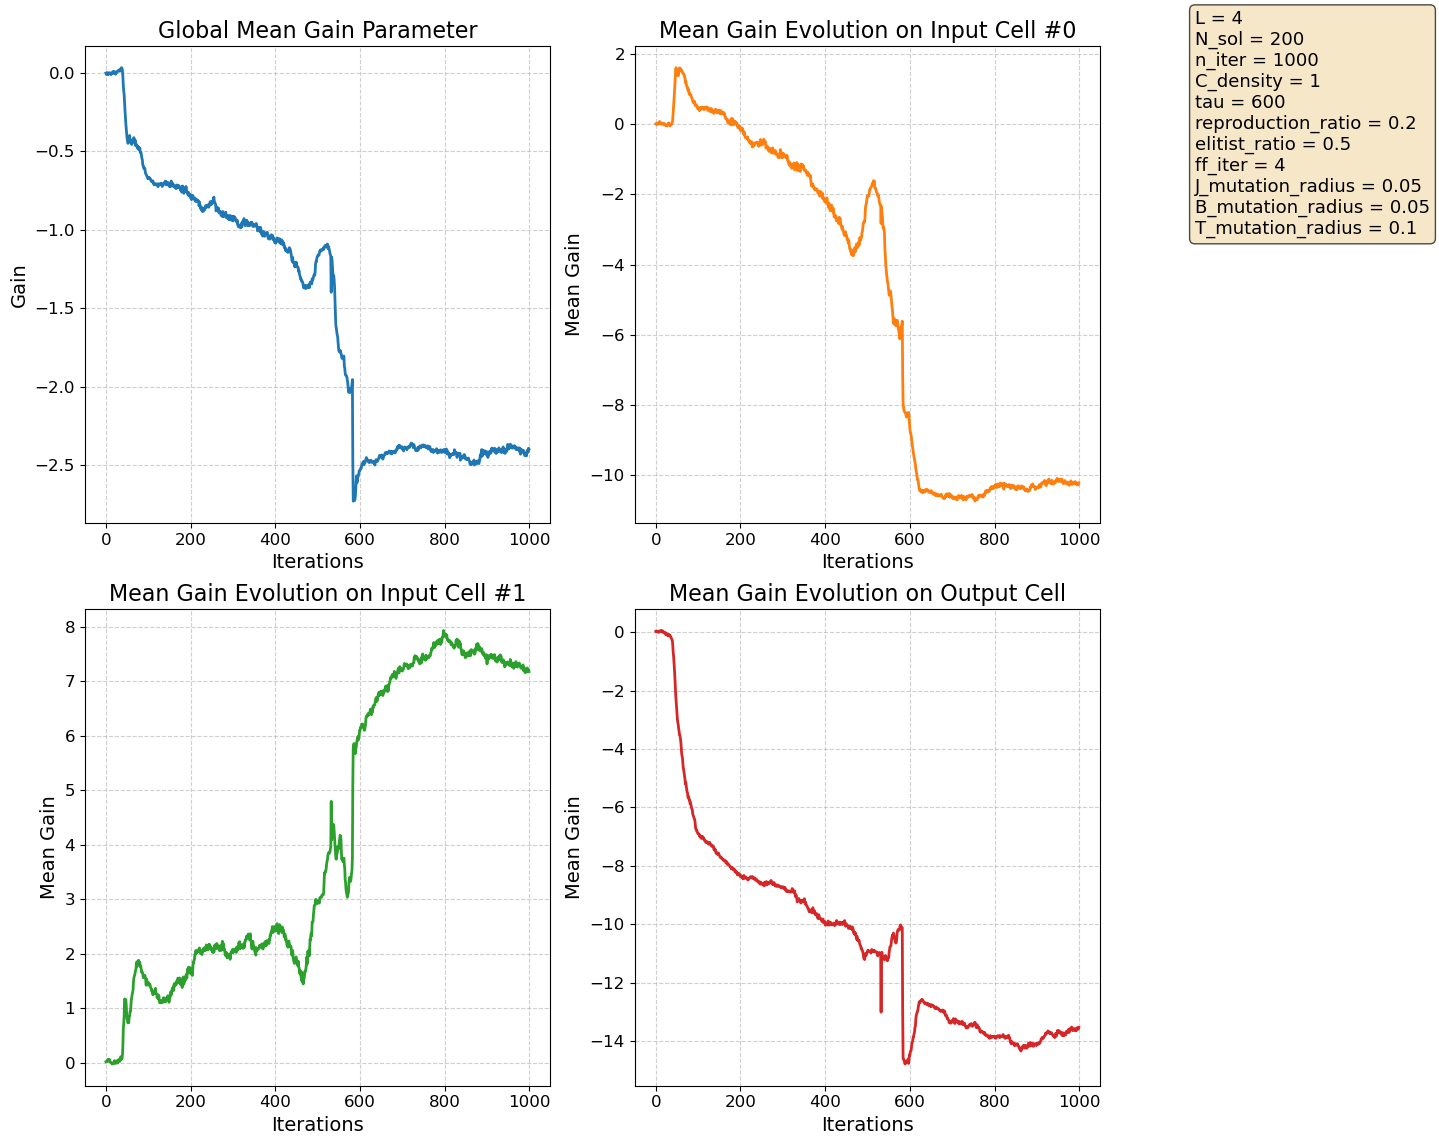

In [14]:
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# Global Mean Gain
axs[0, 0].plot(np.mean(T_values, axis=(0, 1)), color='tab:blue', linewidth=2)
axs[0, 0].set_title('Global Mean Gain Parameter', fontsize=16)
axs[0, 0].set_xlabel('Iterations', fontsize=14)
axs[0, 0].set_ylabel('Gain', fontsize=14)
axs[0, 0].grid(True, linestyle='--', alpha=0.6)
axs[0, 0].tick_params(axis='both', labelsize=12)

# Mean Gain Evolution on Input #0
axs[0, 1].plot(np.mean(T_values[:, par['L']//2, :], axis=0), color='tab:orange', linewidth=2)
axs[0, 1].set_title('Mean Gain Evolution on Input Cell #0', fontsize=16)
axs[0, 1].set_xlabel('Iterations', fontsize=14)
axs[0, 1].set_ylabel('Mean Gain', fontsize=14)
axs[0, 1].grid(True, linestyle='--', alpha=0.6)
axs[0, 1].tick_params(axis='both', labelsize=12)

# Mean Gain Evolution on Input #1
axs[1, 0].plot(np.mean(T_values[:, 2*par['L'], :], axis=0), color='tab:green', linewidth=2)
axs[1, 0].set_title('Mean Gain Evolution on Input Cell #1', fontsize=16)
axs[1, 0].set_xlabel('Iterations', fontsize=14)
axs[1, 0].set_ylabel('Mean Gain', fontsize=14)
axs[1, 0].grid(True, linestyle='--', alpha=0.6)
axs[1, 0].tick_params(axis='both', labelsize=12)

# Mean Gain Evolution on Output
axs[1, 1].plot(np.mean(T_values[:, -1, :], axis=0), color='tab:red', linewidth=2)
axs[1, 1].set_title('Mean Gain Evolution on Output Cell', fontsize=16)
axs[1, 1].set_xlabel('Iterations', fontsize=14)
axs[1, 1].set_ylabel('Mean Gain', fontsize=14)
axs[1, 1].grid(True, linestyle='--', alpha=0.6)
axs[1, 1].tick_params(axis='both', labelsize=12)

# Add parameter box
fig.text(0.75, 0.95, param_text, fontsize=13, va='top', ha='left',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout(rect=[0, 0, 0.7, 1])
plt.subplots_adjust(top=0.92)
plt.savefig('plots/gain.png', dpi=150)
plt.show()


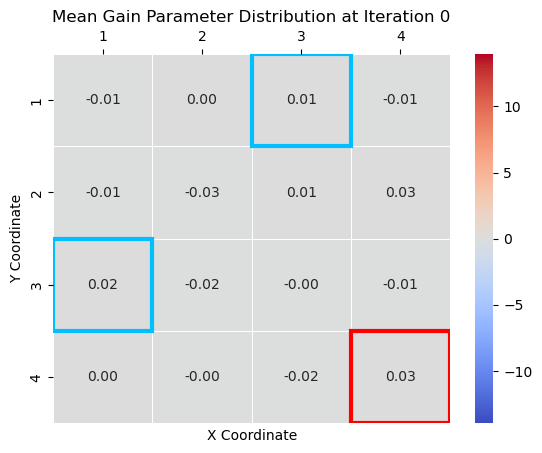

In [15]:
# Prepare mask for highlighting input and output cells
mask = np.zeros((par['L'], par['L']), dtype=bool)
highlight_colors = np.full((par['L'], par['L']), '', dtype=object)

# Highlight input cells (par['L']//2 and 2*par['L']) and output cell (-1)
input_indices = [par['L']//2, 2*par['L']]
output_index = par['L']**2 - 1

for idx in input_indices:
    y, x = divmod(idx, par['L'])
    highlight_colors[y, x] = 'input'
y, x = divmod(output_index, par['L'])
highlight_colors[y, x] = 'output'

# Create a color map for annotations
def highlight_cells(val, color):
    if color == 'input':
        return 'background-color: lightblue'
    elif color == 'output':
        return 'background-color: lightcoral'
    else:
        return ''

data = np.mean(T_values,axis=0)

fig, axes = plt.subplots()
ax = sns.heatmap(
    solutions[n].T.reshape(par['L'], par['L']),
    xticklabels=np.arange(1, par['L']+1),
    yticklabels=np.arange(1, par['L']+1),
    cmap='viridis',
    annot=True,
    fmt=".2f",
    linewidths=.5,
    vmin=np.min(solutions[n].T),
    vmax=np.max(solutions[n].T),
    ax=axes
)

param_text = (
    f"L = {par['L']}\n"
    f"N_sol = {par['N_sol']}\n"
    f"n_iter = {par['n_iter']}\n"
    f"C_density = {par['C_density']}\n"
    f"tau = {par['tau']}\n"
    f"reproduction_ratio = {par['reproduction_ratio']}\n"
    f"elitist_ratio = {par['elitist_ratio']}\n"
    f"ff_iter = {par['ff_iter']}\n"
    f"J_mutation_radius = {par['J_mutation_radius']}\n"
    f"B_mutation_radius = {par['B_mutation_radius']}\n"
    f"T_mutation_radius = {par['T_mutation_radius']}"
)


def animate(i):
    plt.clf()
    frame = data.reshape((par['L'], par['L'], -1))[:, :, i]
    ax = sns.heatmap(
        frame,
        xticklabels=np.arange(1, par['L']+1),
        yticklabels=np.arange(1, par['L']+1),
        cmap='coolwarm',
        annot=True,
        fmt=".2f",
        linewidths=.5,
        vmin=-np.max([np.max(solutions[n].T),np.abs(np.min(solutions[n].T))]),
        vmax=np.max([np.max(solutions[n].T),np.abs(np.min(solutions[n].T))])
    )
    ax.set(xlabel="X Coordinate", ylabel="Y Coordinate")
    ax.set_title(f'Mean Gain Parameter Distribution at Iteration {i}')
    ax.xaxis.tick_top()
    for (y, x), label in np.ndenumerate(highlight_colors):
        if label == 'input':
            ax.add_patch(plt.Rectangle((x, y), 1, 1, fill=False, edgecolor='deepskyblue', lw=3))
        elif label == 'output':
            ax.add_patch(plt.Rectangle((x, y), 1, 1, fill=False, edgecolor='red', lw=3))

ani = animation.FuncAnimation(fig, animate, frames=data.shape[1], interval=50)

ani.save('plots/gain_map.gif', writer='pillow')

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))

param_text = (
    f"L = {par['L']}\n"
    f"N_sol = {par['N_sol']}\n"
    f"n_iter = {par['n_iter']}\n"
    f"C_density = {par['C_density']}\n"
    f"tau = {par['tau']}\n"
    f"reproduction_ratio = {par['reproduction_ratio']}\n"
    f"elitist_ratio = {par['elitist_ratio']}\n"
    f"ff_iter = {par['ff_iter']}\n"
    f"J_mutation_radius = {par['J_mutation_radius']}\n"
    f"B_mutation_radius = {par['B_mutation_radius']}\n"
    f"T_mutation_radius = {par['T_mutation_radius']}"
)

# Move parameter box to the right and center vertically
fig.text(0.98, 0.5, param_text, fontsize=12, va='center', ha='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Use fixed bins for all frames to ensure visibility
bins = np.linspace(np.min(loss_ev), np.max(loss_ev), 50)

def animate(i):
    ax.clear()
    ax.hist(loss_ev[:, i], bins=bins, color='b', alpha=0.7)
    ax.set_title(f'Loss Histogram at Iteration {i+1}')
    ax.set_xlabel('Loss')
    ax.set_ylabel('Population')
    ax.set_xlim(np.min(loss_ev), np.max(loss_ev))
    ax.set_ylim(0, par['N_sol'])

ani = animation.FuncAnimation(fig, animate, frames=loss_ev.shape[1], interval=50)

ani.save('plots/loss_evolution.gif', writer='pillow')
plt.close(fig)